In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"


import IPython.display as ipd
import pandas as pd
import numpy as np
import seaborn as sns
import librosa
import soundfile as sf
import re
import scipy
import torch
import matplotlib.pyplot as plt
import nnAudio
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import gc
import seaborn as sns

from glob import glob
from tqdm import tqdm
from nnAudio.features.mel import MelSpectrogram
from torchaudio.transforms import AmplitudeToDB
from transformers import (
    AutoTokenizer, AutoFeatureExtractor, AutoModelForCTC, 
    AutoProcessor, Wav2Vec2Model, HubertForCTC, 
    HubertModel, Data2VecAudioForCTC, Data2VecAudioModel,
    AutoModelForAudioXVector
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import Pipeline
%matplotlib inline

In [ ]:
DEVICE = "cuda"

# Agenda
1. [Why do we need SSL representations?](#Why_do_we_need_SSL_representations)
2. [Moving from librosa to torchaudio/nnAudio](#TorchAudio)
3. [SSL Audio NNs](#SSL_Audio_NNs)
4. [SSL Features for Speaker Classification](#SSL_Features_for_Speaker_Classification)
5. [Homework](#Homework)
6. [Optional Additional Task](#Optional_Additional_Task)

<a id='Why_do_we_need_SSL_representations'></a>
# Why do we need SSL representations?

Our main goal is to train the better model (in terms of metrics) using a smaller amount of training data.

HOWEVER, accumulating lots of unlabeled data is MUCH easier than labeling even a tiny amount of data.

![unlabaled_data](images/unlabaled_data.png)

![data_labeling](images/data_labeling.png)

How can we benefit from lots of unlabeled data?

![transfer_learning](images/transfer_learning.png)

![weak_supervision](images/weak_supervision.png)

![ssl_features](images/ssl_features.png)

<a id='TorchAudio'></a>
# Moving from `librosa` to `torchaudio`/`nnAudio`?

In [ ]:
# Refactored from https://chat.openai.com/share/e/52f6acc9-152d-4a99-b874-86998ad8fcc7
def load_and_process_audio(paths, sample_rate=None):
    # Load and resample audio files
    audios = []
    max_length = 0
    for path in tqdm(paths):
        audio, sr = librosa.load(path, sr=sample_rate)
        max_length = max(max_length, len(audio))
        audios.append(audio)

    # Pad audios to have the same length and stack them into a batch
    batched_audio = torch.zeros(len(audios), max_length)  # Assuming mono audio files
    padding_masks = torch.zeros(len(audios), max_length)
    for i, audio in enumerate(audios):
        length = len(audio)
        batched_audio[i, :length] = torch.from_numpy(audio)
        padding_masks[i, :length] = 1  # Mark non-padded areas as 1

    return batched_audio, padding_masks

In [ ]:
wave_pathes = glob(
    "../../data/VCTK-Corpus/VCTK-Corpus/wav48/*/*.wav", recursive=True
)
# In case of Windows
wave_pathes = [wave_path.replace('\\', '/') for wave_path in wave_pathes]

speaker2pathes = dict()
for speaker in set([wave_path.split("/")[-2] for wave_path in wave_pathes]):
    speaker2pathes[speaker] = [
        wave_path for wave_path in wave_pathes if wave_path.split("/")[-2] == speaker
    ]

In [ ]:
# Ignore it :) I want to pick "hard" line on the first place
speaker2pathes["p279"] = (
    [speaker2pathes["p279"].pop(speaker2pathes["p279"].index("../../data/VCTK-Corpus/VCTK-Corpus/wav48/p279/p279_202.wav"))]
    +
    speaker2pathes["p279"]
)

In [ ]:
speaker_audio, speaker_pad_mask = load_and_process_audio(speaker2pathes["p279"])

In [ ]:
speaker_audio.shape, speaker_pad_mask.shape

In [ ]:
plt.title("Padded Audio")
plt.plot(speaker_audio[0])
plt.show()
plt.title("UNPadded Audio")
plt.plot(speaker_audio[0][speaker_pad_mask[0].bool()])
plt.show()

> <font style="color:red">**TODO**</font>: Implement "UniversalSlicer", which will be able to cut/pad waves to pre-defined length and batch them. Implement different cutting/padding policies, for example, right/left pad, cut to fixed length or by silence regions (2+ points).

---
## TODO 1 — `UniversalSlicer`

Implements multiple cut/pad policies:
| Policy | Visualization | Description |
| :--- | :--- | :--- |
| `right_pad` | `[████░░░]` | Pad silence on the right *(default, most common)* |
| `left_pad` | `[░░░████]` | Pad silence on the left |
| `center_pad` | `[░█████░]` | Pad silence symmetrically on both sides |
| `cut` | `[████]` | Truncate to `target_length` (from the start) |
| `cut_silence` | `[_██████_]` | Remove leading/trailing silence using energy threshold, then pad/cut |

Returns: `(batched_audio [B, L], padding_mask [B, L])`



In [ ]:
class UniversalSlicer:
    POLICIES = {"right_pad", "left_pad", "center_pad", "cut", "cut_silence"}

    def __init__(
        self,
        target_length: int = None,
        pad_policy: str = "right_pad",
        silence_db: float = -40.0,
    ):
        assert pad_policy in self.POLICIES, f"Unknown policy '{pad_policy}'"
        self.target_length = target_length
        self.pad_policy    = pad_policy
        self.silence_db    = silence_db

    def __call__(self, waves, target_length=None):
        waves_t = [self._to_tensor(w) for w in waves]
        L = target_length or self.target_length or max(len(w) for w in waves_t)

        original_L, self.target_length = self.target_length, L
        results = [self._process_single(w) for w in waves_t]
        self.target_length = original_L

        batched = torch.zeros(len(results), L)
        mask    = torch.zeros(len(results), L)

        for i, (wave, real_length) in enumerate(results):
            batched[i] = wave              
            mask[i, :real_length] = 1.0

        return batched, mask

    def _to_tensor(self, wave):
        if isinstance(wave, np.ndarray):
            return torch.from_numpy(wave.astype(np.float32))
        return wave.float()

    def _process_single(self, wave):
        """Завжди повертає (tensor[L], real_length)."""
        wave = self._to_tensor(wave)
        L    = self.target_length

        if self.pad_policy == "cut_silence":
            wave = self._strip_silence(wave)
            real_length = min(len(wave), L)
            return self._pad(wave, L, mode="right_pad"), real_length

        if self.pad_policy == "cut":
            real_length = min(len(wave), L)
            return self._pad(wave[:L], L, mode="right_pad"), real_length

        # right_pad / left_pad / center_pad
        real_length = min(len(wave), L)
        return self._pad(wave, L, mode=self.pad_policy), real_length

    @staticmethod
    def _pad(wave, L, mode):
        n = len(wave)
        if n >= L:
            return wave[:L]
        needed = L - n
        if mode == "right_pad":
            return F.pad(wave, (0, needed))
        if mode == "left_pad":
            return F.pad(wave, (needed, 0))
        if mode == "center_pad":
            left = needed // 2
            return F.pad(wave, (left, needed - left))
        raise ValueError(f"Unknown pad mode: {mode}")

    def _strip_silence(self, wave):
        frame_size, hop = 512, 256
        frames = wave.unfold(0, frame_size, hop)
        rms_db = 20 * torch.log10(frames.pow(2).mean(dim=1).sqrt().clamp(min=1e-9))
        active = rms_db > self.silence_db
        if not active.any():
            return wave
        first = active.nonzero(as_tuple=True)[0][0].item()
        last  = active.nonzero(as_tuple=True)[0][-1].item()
        return wave[first * hop : min(last * hop + frame_size, len(wave))]

In [ ]:
test_paths = speaker2pathes["p279"][:3]

real_waves = []
for path in test_paths:
    wave, sr = librosa.load(path, sr=None) 
    real_waves.append(wave)


for policy in ["right_pad", "left_pad", "center_pad", "cut", "cut_silence"]:
    slicer = UniversalSlicer(pad_policy=policy)
    audio, mask = slicer(real_waves) 
    
    print(f"[{policy:12s}]  audio={tuple(audio.shape)}  "
          f"active_frames={mask.sum(dim=1).int().tolist()}")

In [ ]:
path = speaker2pathes["p279"][0]
wave, sr = librosa.load(path, sr=None)

print(f"File: {path.split('/')[-1]}")
print(f"Sample rate: {sr} Hz | Length: {len(wave)} samples ({len(wave)/sr:.2f} sec)")

TARGET = 7 * sr
policies = ["right_pad", "left_pad", "center_pad", "cut", "cut_silence"]

fig, axes = plt.subplots(len(policies) + 1, 1, figsize=(14, 16))
time_orig = np.linspace(0, len(wave) / sr, len(wave))

axes[0].plot(time_orig, wave, color="steelblue", linewidth=0.6)
axes[0].set_title(f"Original — {len(wave)} samples ({len(wave)/sr:.2f} sec)", fontsize=11)
axes[0].set_ylabel("Amplitude")
axes[0].axvline(TARGET / sr, color="red", linestyle="--", linewidth=1, label=f"target ({TARGET/sr:.1f}s)")
axes[0].legend(fontsize=8)

# --- Кожна policy ---
for ax, policy in zip(axes[1:], policies):
    slicer = UniversalSlicer(target_length=TARGET, pad_policy=policy)
    audio_batch, mask_batch = slicer([wave])
    
    processed = audio_batch[0].numpy()   # [L]
    mask      = mask_batch[0].numpy()    # [L]
    time_proc = np.linspace(0, TARGET / sr, TARGET)

    # Малюємо сигнал: реальна частина — синя, padding — сіра
    ax.fill_between(time_proc, processed,
                    where=mask == 0,
                    color="lightgray", alpha=0.8, label="padding")
    ax.plot(time_proc, processed,
            color="steelblue", linewidth=0.5, label="signal")

    real_sec = mask.sum() / sr
    ax.set_title(f"{policy}  —  real: {real_sec:.2f}s / {TARGET/sr:.1f}s total", fontsize=11)
    ax.set_ylabel("Amplitude")
    ax.legend(fontsize=8, loc="upper right")

axes[-1].set_xlabel("Time (seconds)")
plt.suptitle(f"UniversalSlicer policies — {path.split('/')[-1]}", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

------

[nnAudio Docs](https://kinwaicheuk.github.io/nnAudio/index.html)

![nnAudio_meme](images/nnAudio_meme.jpg)

In [ ]:
spec_layer =  nn.Sequential(
    MelSpectrogram(sr=48000),
    AmplitudeToDB(top_db=80)
)

In [ ]:
speaker_spec_10 = spec_layer(speaker_audio[:10])

In [ ]:
speaker_spec_10.shape

In [ ]:
def extract_pad_digital_silence_from_spec(input_spec):
    amplitude_sum = input_spec.sum(dim=0)
    pad_start = torch.where(amplitude_sum == amplitude_sum.min())[0].min()
    mask = torch.ones_like(amplitude_sum)
    mask[pad_start:] = 0
    return mask

In [ ]:
plt.title("Padded Spec")
plt.imshow(speaker_spec_10[0])
plt.show()

approx_pad = extract_pad_digital_silence_from_spec(speaker_spec_10[0])

plt.title("Approximated Pad")
plt.plot(approx_pad)
plt.show()
plt.title("Unpad with Approximated Pad")
plt.imshow(speaker_spec_10[0][:,approx_pad==1])
plt.show()

In [ ]:
class Audio2SpecPad(nn.Module):
    def __init__(
        self,
        hop_size=512
    ):
        super().__init__()
        self.maxpool = nn.MaxPool1d(
            kernel_size=hop_size,
            stride=hop_size
        )
    
    def forward(self, audio_pads, time_max_length):
        spec_pads = self.maxpool(audio_pads.unsqueeze(1)).squeeze(1)
        pad = torch.ones(spec_pads.shape[0], time_max_length - spec_pads.shape[-1])
        spec_pads = torch.cat((pad, spec_pads), axis=1)
        return spec_pads
        
audio2spec_pad_layer = Audio2SpecPad()

> <font style="color:red">**TODO**</font>: Rewrite `Audio2SpecPad` and get rid of "hacky pad" (1 point)

---
## TODO 2 — Rewrite `Audio2SpecPad` without the hacky pad

In [ ]:
class Audio2SpecPad2(nn.Module):
    """
    hop_size : int  — STFT hop length (must match the spectrogram layer)
    n_fft    : int  — FFT window size  (must match the spectrogram layer)
    """

    def __init__(self, hop_size: int = 512, n_fft: int = 2048):
        super().__init__()
        self.hop_size = hop_size
        self.n_fft    = n_fft

    def forward(
        self,
        audio_mask: torch.Tensor,   
        time_max_length: int,       
    ) -> torch.Tensor:              

        B = audio_mask.shape[0]
        audio_lengths = audio_mask.sum(dim=1).long() 
        spec_lengths = (
            (audio_lengths - self.n_fft) // self.hop_size + 1
        ).clamp(min=0)              
        
        spec_mask = torch.zeros(B, time_max_length, device=audio_mask.device)
        for i, valid_frames in enumerate(spec_lengths):
            spec_mask[i, :valid_frames] = 1.0

        return spec_mask

In [ ]:
audio2spec2_pad_layer = Audio2SpecPad2()

computed_spec_pad = audio2spec2_pad_layer(
    speaker_pad_mask[:10],
    time_max_length=speaker_spec_10.shape[-1]
)

plt.title("Computed and Approx Pad")
plt.plot(computed_spec_pad[0], label="Computed")
plt.plot(approx_pad, label="Approx")
plt.legend()
plt.show()
plt.title("Unpad with Computed Pad")
plt.imshow(speaker_spec_10[0][:, computed_spec_pad[0] == 1])
plt.show()

---

In [ ]:
computed_spec_pad = audio2spec_pad_layer(
    speaker_pad_mask[:10], 
    time_max_length=speaker_spec_10.shape[-1]
)

plt.title("Computed and Approx Pad")
plt.plot(computed_spec_pad[0], label="Computed")
plt.plot(approx_pad, label="Approx")
plt.legend()
plt.show()
plt.title("Unpad with Computed Pad")
plt.imshow(speaker_spec_10[0][:,computed_spec_pad[0]==1])
plt.show()

<a id='SSL_Audio_NNs'></a>
# SSL Audio NNs

In [ ]:
def parameter_counter(input_model, model_name):
    counter = 0
    for param in input_model.parameters():
        counter += param.shape.numel()
    print(f"{model_name} Parameters Count: {f'{counter/1_000_000:.1f}M'}")

## [Wave2Vec](https://arxiv.org/abs/1904.05862)

Model consists of 2 parts:
- Encoder network $f: X \rightarrow Z$.
- Context network $g: Z \rightarrow C$.

![w2v_logic](images/w2v_logic.png)

The Encoder network produces latent representations, which Context Vector will then predict.

Main ideas:
- Create latent representations containing “averaged for some period” audio information.
- Train Context network, which can “guess” future latent representations.
- Contrastive loss.

![w2v_loss](images/w2v_loss.png)

![w2c_loss_comp](images/w2v_loss_comp.png)

Image taken from [Jonathan Bgn blog](https://jonathanbgn.com/2021/06/29/illustrated-wav2vec.html)


After the model is trained, we can use the output of Encoder network -> Context network ($f(g(\text{audio}))$) as audio representation, which should contain “plenty of phonetic information”.

![w2v_results](images/w2v_results.png)

### Wave2Vec 2.0

Main ideas:
1. They showed that we can learn discrete units from speech without phonetic labels
2. Core of the architecture is transformer encoder
3. Training objective is similar to language modeling objective and adapted for speech

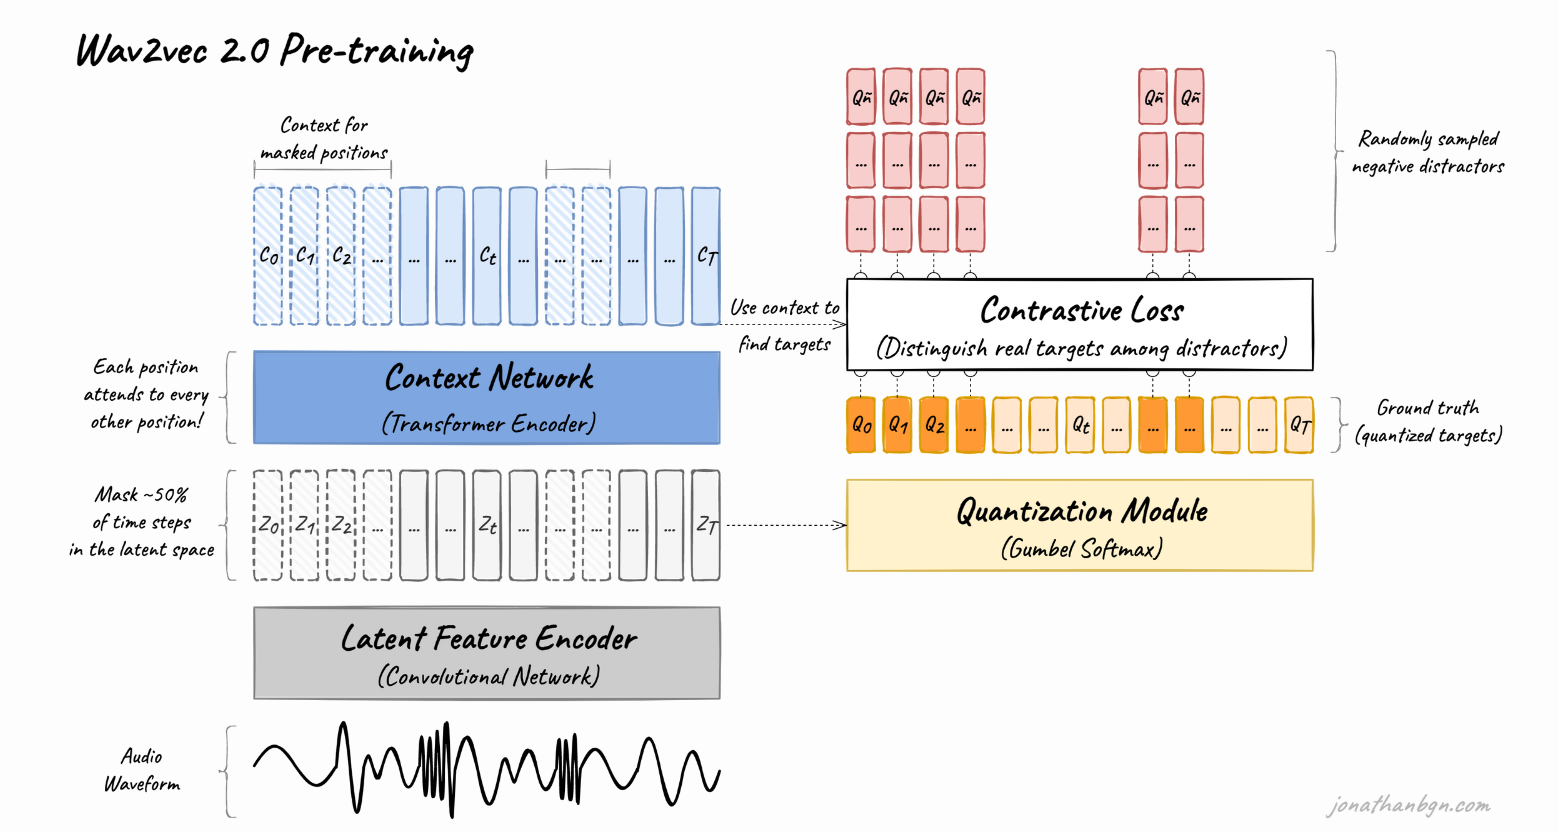
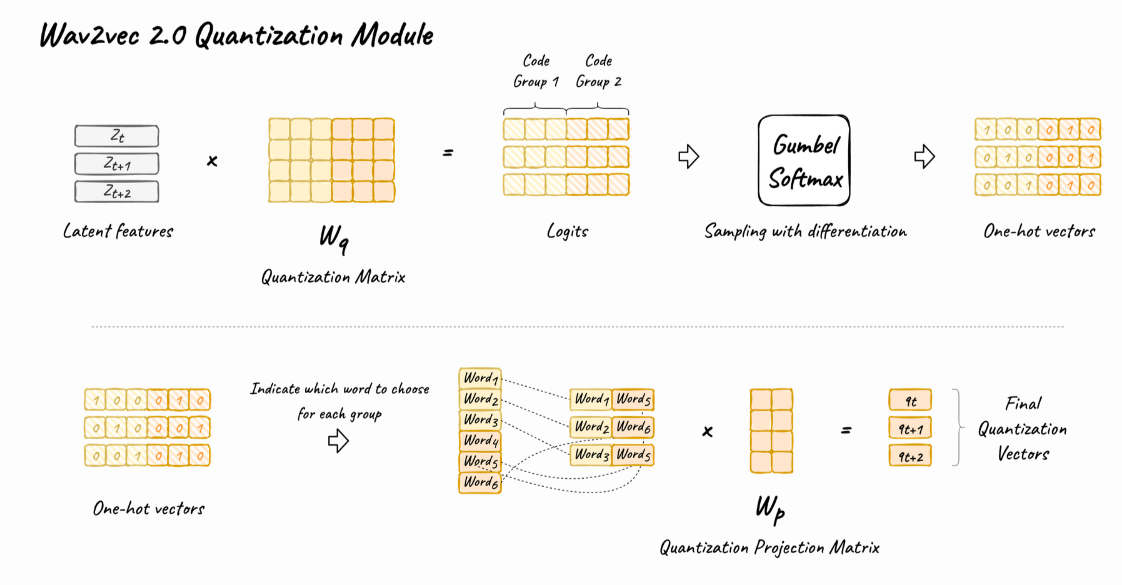

Code example is adopted from official HF example:

- [ASR](https://huggingface.co/docs/transformers/model_doc/wav2vec2#transformers.Wav2Vec2CTCTokenizer).
- [SSL](https://huggingface.co/docs/transformers/model_doc/wav2vec2#transformers.Wav2Vec2Model).

In [ ]:
model = AutoModelForCTC.from_pretrained("facebook/wav2vec2-base-960h").to(DEVICE)
tokenizer = AutoTokenizer.from_pretrained("facebook/wav2vec2-base-960h")
feature_extractor = AutoFeatureExtractor.from_pretrained("facebook/wav2vec2-base-960h")

In [ ]:
type(feature_extractor)

In [ ]:
parameter_counter(model, "W2V")

In [ ]:
resample_layer = torchaudio.transforms.Resample(
    orig_freq=48000,
    new_freq=16000
)

In [ ]:
speaker_audio_10_16k = resample_layer(speaker_audio[:10])

In [ ]:
print(f"Time shape decreased {speaker_audio.shape[-1] / speaker_audio_10_16k.shape[-1]} times after resampling")

In [ ]:
# Process waves
input_values = feature_extractor([
    el for el in speaker_audio_10_16k.numpy()
], return_tensors="pt").input_values

In [ ]:
plt.title("16K audio")
plt.plot(speaker_audio_10_16k[0])
plt.show()
plt.title("W2V Processed audio")
plt.plot(input_values[0])
plt.show()

> <font style="color:red">**TODO**</font>: Explore [Wav2Vec2FeatureExtractor](https://huggingface.co/docs/transformers/model_doc/wav2vec2#transformers.Wav2Vec2FeatureExtractor). Can we rewrite it, so it takes on input batched torch.Tensor ? (1 point)

---
## TODO 3 — `Wav2Vec2FeatureExtractor` accepting batched `torch.Tensor`

In [ ]:
class BatchedWav2Vec2FeatureExtractor:
    """
    do_normalize : bool — if True, apply per-utterance mean/std normalization
                          (matches the default HF behaviour)
    """

    def __init__(self, do_normalize: bool = True):
        self.do_normalize = do_normalize

    def __call__(
        self,
        waveforms:     torch.Tensor,   # [B, L] zero-padded batch
        padding_masks: torch.Tensor,   # [B, L] 1 = real, 0 = padding
    ) -> torch.Tensor:                 # [B, L] normalised input_values

        waveforms = waveforms.double()
        masks     = padding_masks.double()

        if not self.do_normalize:
            return waveforms

        lengths = masks.sum(dim=1, keepdim=True).clamp(min=1)   # [B, 1]
        mean = (waveforms * masks).sum(dim=1, keepdim=True) / lengths  # [B, 1]

        sq_diff = ((waveforms - mean) * masks) ** 2
        std = (sq_diff.sum(dim=1, keepdim=True) / lengths + 1e-7).sqrt()     # [B, 1]

        normed = ((waveforms - mean) / std) * masks

        return normed.float()

def verify_against_hf(n_samples=4, length=16_000):
    from transformers import Wav2Vec2FeatureExtractor as HFExtractor

    hf_extractor  = HFExtractor.from_pretrained("facebook/wav2vec2-base-960h")
    our_extractor = BatchedWav2Vec2FeatureExtractor(do_normalize=True)

    real_lengths = torch.randint(8_000, length, (n_samples,))
    raw_waves    = torch.randn(n_samples, length)

    for i in range(n_samples):
        l = real_lengths[i]
        x = raw_waves[i, :l]                    

        
        hf_in  = hf_extractor(
            x.numpy(), sampling_rate=16_000, return_tensors="pt"
        ).input_values                           
        
        mask   = torch.ones(1, l)
        our_in = our_extractor(x.unsqueeze(0), mask)   

        diff = (hf_in[0] - our_in[0]).abs()
        assert diff.max() < 1e-4, "Mismatch!"

    print("✓ BatchedWav2Vec2FeatureExtractor matches HF reference.")

In [ ]:
verify_against_hf()

---

In [ ]:
# Apply Model
with torch.no_grad():
    model_output = model(input_values.cuda())

In [ ]:
print(f"Input Shape [B, L]: {input_values.shape}")
print(f"Ouput Shape [B, N_L, C]: {model_output.logits.shape}")

I assume that `C` (number of classes) here refer to number of letter in English + a bunch of special symbols. BUT

> **TODO**: Check what does [Wav2Vec2ForCTC("facebook/wav2vec2-base-960h")](https://huggingface.co/facebook/wav2vec2-base-960h) predict ?

---

| token | meaning |
|-------|---------|
| `A`–`Z` (26 tokens) | uppercase English letters |
| `\|` | word boundary (space between words) |
| `[UNK]` | unknown character |
| `[PAD]` | CTC blank token (used to collapse repeated predictions) |
| `'` | apostrophe (contraction marker) |

In [ ]:
print(tokenizer.get_vocab())
print(f"Vocabulary size: {len(tokenizer.get_vocab())}")

---

In [ ]:
# Decode results
pred_ids = torch.argmax(model_output.logits[0], axis=-1)
outputs = tokenizer.decode(pred_ids, output_word_offsets=True)
outputs.text

In [ ]:
ipd.Audio(
    data=speaker_audio_10_16k[0],
    rate=16_000
)

In [ ]:
!cat {speaker2pathes["p279"][0].replace("wav48", "txt").replace(".wav",".txt")}

In [ ]:
# Free memory 
del model, tokenizer, feature_extractor
torch.cuda.empty_cache()
gc.collect()

But we are not really intersted in ASR now, it is just a cool bonus :)

Lets come back to our SSL features

In [ ]:
processor = AutoProcessor.from_pretrained("facebook/wav2vec2-base-960h")
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h").to(DEVICE)

In [ ]:
input_values = processor([
    el for el in speaker_audio_10_16k.numpy()
], sampling_rate=16_000, return_tensors="pt")

In [ ]:
plt.title("16K audio")
plt.plot(speaker_audio_10_16k[0])
plt.show()
plt.title("W2V Processed audio")
plt.plot(input_values.input_values[0])
plt.show()

In [ ]:
with torch.no_grad():
    model_output = model(input_values.input_values.cuda())

In [ ]:
speaker_w2v_10 = model_output.last_hidden_state.cpu()

In [ ]:
print("Reduction Factor (OR Hop Size) from 16K audio:", input_values.input_values.shape[1] / speaker_w2v_10.shape[1])

In [ ]:
audio2spec_pad_layer = Audio2SpecPad(hop_size=320 * 3)

computed_w2v_pad = audio2spec_pad_layer(
    speaker_pad_mask[:10], 
    time_max_length=speaker_w2v_10.shape[1]
)

In [ ]:
plt.title("Padded W2V")
plt.imshow(speaker_w2v_10[0].T)
plt.show()
plt.title("Unpad with Computed Pad")
plt.imshow(speaker_w2v_10[0][computed_w2v_pad[0]==1].T)
plt.show()

> <span style="color:red">**TODO**</span>: Explore [Wav2Vec2Model](https://huggingface.co/docs/transformers/model_doc/wav2vec2#transformers.Wav2Vec2Model) docs and use `attention_mask` in order to optimize computations and unpad seuqnce in a bettter way (0.5 point).

----

## TODO 5 — Use `attention_mask` with `Wav2Vec2Model` (0.5 point)

In [ ]:
def extract_w2v_with_attention_mask(
    model,          # Wav2Vec2Model on device
    processor,      # AutoProcessor
    waveforms,      # list of 1-D np.ndarray  OR  [B, L] torch.Tensor
    sample_rate: int = 16_000,
    device: str = "cuda",
):
    """
    hidden_states : torch.Tensor [B, T_max, 768]
    output_mask   : torch.Tensor [B, T_max]  — 1 = valid frame, 0 = padding
    """
    # --- 1. Feature extraction & padding ---
    if isinstance(waveforms, torch.Tensor):
        wave_list = [waveforms[i].numpy() for i in range(len(waveforms))]
    else:
        wave_list = waveforms

    inputs = processor(
        wave_list,
        sampling_rate=sample_rate,
        return_tensors="pt",
        padding=True,           
        return_attention_mask=True,  
    )

    input_values  = inputs.input_values.to(device)   # [B, L]
    attention_mask = inputs.attention_mask.to(device) # [B, L] 

    # --- 2. Forward pass WITH attention_mask ---
    with torch.no_grad():
        output = model(
            input_values,
            attention_mask=attention_mask,  
        )

    hidden_states = output.last_hidden_state   # [B, T_max, C]

    # --- 3. Derive output-level mask analytically ---
    audio_lengths  = attention_mask.sum(dim=1)                     # [B]
    output_lengths = model._get_feat_extract_output_lengths(audio_lengths)  # [B]

    T_max       = hidden_states.shape[1]
    output_mask = torch.zeros(len(wave_list), T_max, device=device)
    for i, valid in enumerate(output_lengths):
        output_mask[i, :valid] = 1.0
    
    return hidden_states, output_mask

----

In [ ]:
# Free memory 
del model, processor
torch.cuda.empty_cache()
gc.collect()

## [Hubert](https://arxiv.org/abs/2106.07447)

Model, which is able to predict discrete speech representations.

Overall Pipeline:
1. Cluster MFCC audio representations.
2. Train Masked CNN->Transformer model to predict masked regions.

![hubert_concept](images/hubert_concept.png)

Main ideas:
- Clustered representations may correlate with phonemes.
- In order to “guess” masked regions model should understand audio structure.
- Deeper architecture compared to W2V, in order to create more "high level" audio representations.

![hubert_architecture](images/hubert_architecture.png)

After model is trained we can use HuBERT part to create self supervised audio representations.

![hubert_results](images/hubert_results.png)

Code example is adopted from official HF example:

- [ASR](https://huggingface.co/docs/transformers/model_doc/hubert#transformers.HubertForCTC).
- [SSL](https://huggingface.co/docs/transformers/model_doc/hubert#transformers.HubertModel).

In [ ]:
processor = AutoProcessor.from_pretrained("facebook/hubert-large-ls960-ft")
model = HubertForCTC.from_pretrained("facebook/hubert-large-ls960-ft").to(DEVICE)

In [ ]:
model = HubertForCTC.from_pretrained(
    "facebook/hubert-large-ls960-ft", 
    use_safetensors=True
).to(DEVICE)

In [ ]:
parameter_counter(model, "Hubert")

In [ ]:
input_values = processor([
    el for el in speaker_audio_10_16k.numpy()
], sampling_rate=16_000, return_tensors="pt")

In [ ]:
plt.title("16K audio")
plt.plot(speaker_audio_10_16k[0])
plt.show()
plt.title("Hubert Processed audio")
plt.plot(input_values.input_values[0])
plt.show()

In [ ]:
with torch.no_grad():
    model_output = model(input_values.input_values.cuda())

In [ ]:
print(f"Input Shape [B, L]: {input_values.input_values.shape}")
print(f"Ouput Shape [B, N_L, C]: {model_output.logits.shape}")

In [ ]:
pred_ids = torch.argmax(model_output.logits[0], axis=-1)
transcription = processor.batch_decode(pred_ids)

In [ ]:
transcription[:5]

In [ ]:
" ".join([el for el in transcription if el!="<pad>"])

> <font style="color:red">**TODO**</font>: Check how to normalize outputs of [HubertForCTC](https://huggingface.co/docs/transformers/model_doc/hubert#transformers.HubertForCTC). *Simply put, make them in a format we had for W2V.* (2 points)

---
## TODO 6 — Normalize `HubertForCTC` outputs to W2V format (2 points)

In [ ]:
def decode_hubert_ctc(
    model_output,          # output of HubertForCTC.forward()
    processor,             # AutoProcessor for the same model
    skip_special_tokens: bool = True,
) -> list:
    """
    model_output : CausalLMOutput — direct output of model(input_values)
    processor    : the AutoProcessor used to load the model
    """
    pred_ids = torch.argmax(model_output.logits, dim=-1)   # [B, T]

    transcriptions = processor.batch_decode(
        pred_ids,
        skip_special_tokens=skip_special_tokens,
    )

    return transcriptions   # List[str]

In [ ]:
old_result = " ".join([el for el in transcription if el != "<pad>"])

new_results = decode_hubert_ctc(model_output, processor)

print("СТАРИЙ (logits[0] → 1D → символи):")
print(" ", old_result)
print()
print("НОВИЙ (logits → 2D [B,T] → слова):")
for i, text in enumerate(new_results):
    print(f"  [{i}]", text)

---

Overall, if we normalize Hubert outputs, we can see that (on this particular sample) it performs better:

- W2V: `GYDINES`, Hubert: `G U Y D L I N E S`, GT: `guidelines`.
- W2V: `FINE LINES`, Hubert: `F I N N A L I Z E D`, GT: `finalised`.

In [ ]:
# Free memory 
del model, processor
torch.cuda.empty_cache()
gc.collect()

In [ ]:
processor = AutoProcessor.from_pretrained("facebook/hubert-large-ls960-ft")
model = HubertModel.from_pretrained("facebook/hubert-large-ls960-ft").to(DEVICE)

In [ ]:
model = HubertForCTC.from_pretrained(
    "facebook/hubert-large-ls960-ft", 
    use_safetensors=True
).to(DEVICE)

In [ ]:
input_values = processor([
    el for el in speaker_audio_10_16k.numpy()
], sampling_rate=16_000, return_tensors="pt")

In [ ]:
with torch.no_grad():
    speaker_hubert_10 = model(input_values.input_values.cuda()).last_hidden_state.cpu()

In [ ]:
speaker_hubert_10.shape

In [ ]:
plt.title("Padded Hubert")
plt.imshow(speaker_hubert_10[0].T)
plt.show()
plt.title("Unpad with Computed Pad")
plt.imshow(speaker_hubert_10[0][computed_w2v_pad[0]==1].T)
plt.show()

In [ ]:
# Free memory 
del model, processor
torch.cuda.empty_cache()
gc.collect()

## [Data2Vec](https://arxiv.org/pdf/2202.03555.pdf)

Model is distilled to predict its own representations from previous updates, given a masked input

Pipeline:
1. Encode audio sample with the Teacher model.
2. Mask some sample content and encode it with the Student model.
3. Optimize the Student model, so it produces same representation as the Teacher model.
4. Update the Teacher model with Exponential Moving Average of Student's weights.

![d2v_concept](images/d2v_concept.png)

Main ideas:

- It is a kind of combination of Wave2Vec and Hubert ideas.
- Operates only on its own data representations.
- Representations “to predict” come from the transformer.

![d2v_loss](images/d2v_loss.png)

![d2v_results](images/d2v_results.png)

Code example is adopted from official HF example:

- [ASR](https://huggingface.co/docs/transformers/model_doc/data2vec#transformers.Data2VecAudioForCTC).
- [SSL](https://huggingface.co/docs/transformers/model_doc/data2vec#transformers.Data2VecAudioModel).

In [ ]:
processor = AutoProcessor.from_pretrained("facebook/data2vec-audio-base-960h")
model = Data2VecAudioForCTC.from_pretrained("facebook/data2vec-audio-base-960h").to(DEVICE)

In [ ]:
parameter_counter(model, "D2V")

In [ ]:
input_values = processor([
    el for el in speaker_audio_10_16k.numpy()
], sampling_rate=16_000, return_tensors="pt")

In [ ]:
plt.title("16K audio")
plt.plot(speaker_audio_10_16k[0])
plt.show()
plt.title("D2V Processed audio")
plt.plot(input_values.input_values[0])
plt.show()

In [ ]:
with torch.no_grad():
    model_output = model(input_values.input_values.cuda())

In [ ]:
print(f"Input Shape [B, L]: {input_values.input_values.shape}")
print(f"Ouput Shape [B, N_L, C]: {model_output.logits.shape}")

In [ ]:
pred_ids = torch.argmax(model_output.logits[0], axis=-1)
transcription = processor.batch_decode(pred_ids)

In [ ]:
transcription[:5]

In [ ]:
" ".join([el for el in transcription if el!="<pad>"])

Overall, if we normalize D2V outputs, we can see that (on this particular sample) it performs the worst :) :

- W2V: `GYDINES`, Hubert: `G U Y D L I N E S`, D2V: `G U Y L I N E S S`, GT: `guidelines`
- W2V: `FINE LINES`, Hubert: `F I N N A L I Z E D`, D2V: `F I N E L I N E S S`, GT: `finalised`

In [ ]:
# Free memory 
del model, processor
torch.cuda.empty_cache()
gc.collect()

In [ ]:
processor = AutoProcessor.from_pretrained("facebook/data2vec-audio-base-960h")
model = Data2VecAudioModel.from_pretrained("facebook/data2vec-audio-base-960h").to(DEVICE)

In [ ]:
with torch.no_grad():
    speaker_d2v_10 = model(input_values.input_values.cuda()).last_hidden_state.cpu()

In [ ]:
speaker_d2v_10.shape

In [ ]:
plt.title("Padded D2V")
plt.imshow(speaker_d2v_10[0].T)
plt.show()
plt.title("Unpad with Computed Pad")
plt.imshow(speaker_d2v_10[0][computed_w2v_pad[0]==1].T)
plt.show()

In [ ]:
# Free memory 
del model, processor
torch.cuda.empty_cache()
gc.collect()

## Hot to train SSL models ?

Code for training is adapted from [transformers examples](https://github.com/huggingface/transformers/tree/main/examples/pytorch/speech-pretraining)

In [ ]:
import torch
from torch.utils.data import DataLoader
import math
import os
from dataclasses import dataclass
from typing import Dict, List, Optional, Union
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import datasets
from datasets import load_dataset, concatenate_datasets, DatasetDict
from transformers import (
    AdamW,
    Wav2Vec2Config,
    Wav2Vec2FeatureExtractor,
    Wav2Vec2ForPreTraining,
    get_scheduler,
    set_seed
)
from transformers.models.wav2vec2.modeling_wav2vec2 import _compute_mask_indices, _sample_negative_indices

# Set up logging
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

In [ ]:
class PretrainingConfig:
    def __init__(self):
        # Dataset parameters
        self.dataset_name = "librispeech_asr"
        self.dataset_config_names = ["clean", "clean"]
        self.dataset_split_names = ["validation", "test"]
        self.audio_column_name = "audio"
        self.max_duration_in_seconds = 20.0
        self.min_duration_in_seconds = 2.0
        self.validation_split_percentage = 1
        
        # Model parameters
        self.model_name_or_path = "patrickvonplaten/wav2vec2-base-v2"
        self.mask_time_prob = 0.65
        self.mask_time_length = 10
        self.gradient_checkpointing = True
        
        # Training parameters
        self.seed = 42
        self.train_batch_size = 2
        self.eval_batch_size = 2
        self.gradient_accumulation_steps = 8
        self.learning_rate = 1e-5
        self.adam_beta1 = 0.9
        self.adam_beta2 = 0.98
        self.adam_epsilon = 1e-06
        self.weight_decay = 0.01
        self.max_train_steps = 20000
        self.num_warmup_steps = 32000
        self.max_gumbel_temperature = 2.0
        self.min_gumbel_temperature = 0.5
        self.gumbel_temperature_decay = 0.999995
        self.pad_to_multiple_of = None
        
        # Output parameters
        self.output_dir = "./wav2vec2-pretrained-demo"
        self.logging_steps = 10
        self.saving_steps = 1000
        
        # Scheduler
        self.lr_scheduler_type = "linear"
        self.num_train_epochs = 5
        self.device = torch.device("cuda")

In [ ]:
@dataclass
class DataCollatorForWav2Vec2Pretraining: # Copy from transformers/examples/pytorch/speech-pretraining/run_wav2vec2_pretraining_no_trainer.py
    model: Wav2Vec2ForPreTraining
    feature_extractor: Wav2Vec2FeatureExtractor
    padding: Union[bool, str] = "longest"
    pad_to_multiple_of: Optional[int] = None
    mask_time_prob: Optional[float] = 0.65
    mask_time_length: Optional[int] = 10
    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        # reformat list to dict and set to pytorch format
        batch = self.feature_extractor.pad(
            features,
            padding=self.padding,
            pad_to_multiple_of=self.pad_to_multiple_of,
            return_tensors="pt",

        )
        
        device = next(self.model.parameters()).device
        batch = {k: v.to(device) for k, v in batch.items()}

        batch_size = batch["input_values"].shape[0]

        mask_indices_seq_length = self.model._get_feat_extract_output_lengths(batch["input_values"].shape[-1])
        # make sure masked sequence length is a Python scalar
        mask_indices_seq_length = int(mask_indices_seq_length)

        # make sure that no loss is computed on padded inputs
        if batch.get("attention_mask") is not None:
            # compute real output lengths according to convolution formula
            batch["sub_attention_mask"] = self.model._get_feature_vector_attention_mask(
                mask_indices_seq_length, batch["attention_mask"]
            )

        features_shape = (batch_size, mask_indices_seq_length)

        # sample randomly masked indices
        mask_time_indices = _compute_mask_indices(
            features_shape,
            self.mask_time_prob,
            self.mask_time_length,
            attention_mask=batch.get("sub_attention_mask"),
        )

        # sample negative indices
        sampled_negative_indices = _sample_negative_indices(
            features_shape,
            self.model.config.num_negatives,
            mask_time_indices=mask_time_indices,
        )
        batch["mask_time_indices"] = torch.tensor(mask_time_indices, dtype=torch.long, device=device)
        batch["sampled_negative_indices"] = torch.tensor(sampled_negative_indices, dtype=torch.long, device=device)

        return batch

def multiply_grads(params, c):
    for p in params:
        if p.grad is not None:
            if torch.is_tensor(c):
                c = c.to(p.grad.device)
            p.grad.data.mul_(c)


def get_grad_norm(params, scale=1):
    total_norm = 0.0
    for p in params:
        if p.grad is not None:
            param_norm = (p.grad.detach().data / scale).norm(2)
            total_norm += param_norm.item() ** 2
    total_norm = total_norm**0.5
    return total_norm

In [ ]:
def prepare_datasets(config):
    datasets_splits = []
    for dataset_config_name, split_name in zip(config.dataset_config_names, config.dataset_split_names):
        print(split_name, dataset_config_name)
        dataset_split = load_dataset(
            config.dataset_name,
            dataset_config_name,
            split=split_name,
        )
        datasets_splits.append(dataset_split)

    raw_datasets = DatasetDict()
    if len(datasets_splits) > 1:
        raw_datasets["train"] = concatenate_datasets(datasets_splits).shuffle(seed=config.seed)
    else:
        raw_datasets["train"] = datasets_splits[0]

    # Create validation split
    num_validation_samples = raw_datasets["train"].num_rows * config.validation_split_percentage // 100
    if num_validation_samples == 0:
        raise ValueError(
            f"Validation split percentage is too small for {len(raw_datasets['train'])} training samples."
        )

    raw_datasets["validation"] = raw_datasets["train"].select(range(num_validation_samples))
    raw_datasets["train"] = raw_datasets["train"].select(range(num_validation_samples, raw_datasets["train"].num_rows))

    feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(config.model_name_or_path)

    # Ensure dataset has the correct sampling rate
    raw_datasets = raw_datasets.cast_column(
        config.audio_column_name, datasets.features.Audio(sampling_rate=feature_extractor.sampling_rate)
    )

    max_length = int(config.max_duration_in_seconds * feature_extractor.sampling_rate)
    min_length = int(config.min_duration_in_seconds * feature_extractor.sampling_rate)

    def prepare_dataset(batch):
        sample = batch[config.audio_column_name]
        inputs = feature_extractor(
            sample["array"], sampling_rate=sample["sampling_rate"], max_length=max_length, truncation=True
        )
        batch["input_values"] = inputs.input_values[0]
        batch["input_length"] = len(inputs.input_values[0])
        return batch

    print("Processing datasets...")
    vectorized_datasets = raw_datasets.map(
        prepare_dataset,
        remove_columns=raw_datasets["train"].column_names,
    )

    # Filter by minimum length
    if min_length > 0:
        vectorized_datasets = vectorized_datasets.filter(
            lambda x: x > min_length,
            input_columns=["input_length"],
        )

    vectorized_datasets = vectorized_datasets.remove_columns("input_length")
    
    print(f"Training dataset size: {len(vectorized_datasets['train'])}")
    print(f"Validation dataset size: {len(vectorized_datasets['validation'])}")
    
    return vectorized_datasets, feature_extractor

In [ ]:
def setup_model_and_training(config, vectorized_datasets, feature_extractor):
    # Load model config
    model_config = Wav2Vec2Config.from_pretrained(config.model_name_or_path)
    
    # Check if config is compatible with pretraining
    if not model_config.do_stable_layer_norm or model_config.feat_extract_norm != "layer":
        raise ValueError(
            "PreTraining requires config.do_stable_layer_norm=True and config.feat_extract_norm='layer'"
        )
    
    model = Wav2Vec2ForPreTraining(model_config)
    model = model.to(config.device)
    
    if config.gradient_checkpointing:
        model.gradient_checkpointing_enable()
    
    mask_time_prob = model_config.mask_time_prob if config.mask_time_prob is None else config.mask_time_prob
    mask_time_length = model_config.mask_time_length if config.mask_time_length is None else config.mask_time_length
    
    data_collator = DataCollatorForWav2Vec2Pretraining(
        model=model,
        feature_extractor=feature_extractor,
        pad_to_multiple_of=config.pad_to_multiple_of,
        mask_time_prob=mask_time_prob,
        mask_time_length=mask_time_length,
    )
    
    train_dataloader = DataLoader(
        vectorized_datasets["train"],
        shuffle=True,
        collate_fn=data_collator,
        batch_size=config.train_batch_size,
    )
    
    eval_dataloader = DataLoader(
        vectorized_datasets["validation"],
        collate_fn=data_collator,
        batch_size=config.eval_batch_size,
    )
    
    optimizer = AdamW(
        list(model.parameters()),
        lr=config.learning_rate,
        betas=[config.adam_beta1, config.adam_beta2],
        eps=config.adam_epsilon,
        weight_decay=config.weight_decay,
    )
    
    num_update_steps_per_epoch = math.ceil(len(train_dataloader) / config.gradient_accumulation_steps)
    
    if config.max_train_steps is None:
        config.max_train_steps = config.num_train_epochs * num_update_steps_per_epoch
    
    lr_scheduler = get_scheduler(
        name=config.lr_scheduler_type,
        optimizer=optimizer,
        num_warmup_steps=config.num_warmup_steps,
        num_training_steps=config.max_train_steps,
    )
    
    config.num_train_epochs = math.ceil(config.max_train_steps / num_update_steps_per_epoch)
    
    return model, optimizer, lr_scheduler, train_dataloader, eval_dataloader, num_update_steps_per_epoch

In [ ]:
def init_training():
    config = PretrainingConfig()
    
    set_seed(config.seed)
    vectorized_datasets, feature_extractor = prepare_datasets(config)
    
    model, optimizer, lr_scheduler, train_dataloader, eval_dataloader, num_update_steps_per_epoch = setup_model_and_training(
        config, vectorized_datasets, feature_extractor
    )
    
    os.makedirs(config.output_dir, exist_ok=True)
    return config, model, optimizer, lr_scheduler, train_dataloader, eval_dataloader, num_update_steps_per_epoch

In [ ]:
config, model, optimizer, lr_scheduler, train_dataloader, eval_dataloader, num_update_steps_per_epoch = init_training()

completed_steps = 0
train_losses = []
val_losses = []
learning_rates = []

progress_bar = tqdm(range(config.max_train_steps), desc="Training")

# Main training loop
for epoch in range(config.num_train_epochs):
    model.train()
    epoch_loss = 0
    
    epoch_progress = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{config.num_train_epochs}", leave=False)
    
    for step, batch in enumerate(epoch_progress):
        num_losses = batch["mask_time_indices"].sum()
        sub_attention_mask = batch.pop("sub_attention_mask", None)
        if sub_attention_mask is None:
            sub_attention_mask = torch.ones_like(batch["mask_time_indices"])
        percent_masked = num_losses / sub_attention_mask.sum()
        
        outputs = model(**batch)
        
        loss = outputs.loss / config.gradient_accumulation_steps
        epoch_loss += loss.item()
        
        loss.backward()
        multiply_grads(model.parameters(), 1 / num_losses)
        
        if (step + 1) % config.gradient_accumulation_steps == 0 or step == len(train_dataloader) - 1:
            grad_norm = get_grad_norm(model.parameters())
            
            optimizer.step()
            optimizer.zero_grad()
            
            lr_scheduler.step()
            
            gumbel_temperature = max(
                config.max_gumbel_temperature * config.gumbel_temperature_decay**completed_steps,
                config.min_gumbel_temperature,
            )
            model.set_gumbel_temperature(gumbel_temperature)
            
            progress_bar.update(1)
            completed_steps += 1
            
            learning_rates.append(optimizer.param_groups[0]["lr"])
        
        if (step + 1) % (config.gradient_accumulation_steps * config.logging_steps) == 0:
            loss_value = loss.item() * config.gradient_accumulation_steps
            
            train_losses.append(loss_value)
            
            log_dict = {
                "loss": loss_value,
                "contrast_loss": outputs.contrastive_loss.item() / num_losses.item(),
                "div_loss": outputs.diversity_loss.item() / num_losses.item(),
                "mask_percent": percent_masked.item(),
                "perplexity": outputs.codevector_perplexity.item(),
                "lr": optimizer.param_groups[0]["lr"],
                "temp": gumbel_temperature,
                "grad_norm": grad_norm,
            }
            
            epoch_progress.set_postfix(**{k: f"{v:.4f}" for k, v in log_dict.items() if k in ["loss", "lr"]})
            
            log_str = f"Step: {completed_steps}/{config.max_train_steps}"
            for k, v in log_dict.items():
                log_str += f" | {k}: {v:.4f}"
            logger.info(log_str)
        
        if (step + 1) % (config.gradient_accumulation_steps * config.saving_steps) == 0:
            output_checkpoint_dir = os.path.join(config.output_dir, f"checkpoint-{completed_steps}")
            os.makedirs(output_checkpoint_dir, exist_ok=True)
            
            model.save_pretrained(output_checkpoint_dir)
            logger.info(f"Saved checkpoint to {output_checkpoint_dir}")
        
        if completed_steps >= config.max_train_steps:
            break
    
    model.eval()
    val_loss = 0.0
    val_contrastive_loss = 0.0
    val_diversity_loss = 0.0
    val_num_losses = 0
    
    logger.info("Running validation...")
    for batch in tqdm(eval_dataloader, desc="Validation", leave=False):
        with torch.no_grad():
            batch.pop("sub_attention_mask", None)
            outputs = model(**batch)
        
        val_loss += outputs.loss.item()
        val_contrastive_loss += outputs.contrastive_loss.item()
        val_diversity_loss += outputs.diversity_loss.item()
        val_num_losses += batch["mask_time_indices"].sum().item()
    
    avg_val_loss = val_loss / val_num_losses
    val_losses.append(avg_val_loss)
    
    logger.info(f"Validation results - Epoch {epoch+1}/{config.num_train_epochs}:")
    logger.info(f"  Loss: {avg_val_loss:.4f}")
    logger.info(f"  Contrastive loss: {val_contrastive_loss / val_num_losses:.4f}")
    logger.info(f"  Diversity loss: {val_diversity_loss / val_num_losses:.4f}")
    
#    if (epoch + 1) % 2 == 0 or epoch == config.num_train_epochs - 1:
#        plot_training_metrics(train_losses, val_losses, learning_rates)

model.save_pretrained(config.output_dir)
logger.info(f"Training completed! Final model saved to {config.output_dir}")

# plot_training_metrics(train_losses, val_losses, learning_rates)

trained_model = model
metrics = {
    "train_losses": train_losses,
    "val_losses": val_losses,
    "learning_rates": learning_rates
}

## How to benchmark SSL models ?

The most popular approach is [SUPERB: Speech processing Universal PERformance Benchmark](https://arxiv.org/abs/2105.01051).

Using this benchmark, we evaluate SSL models (SSL Model -> "Head") on the following tasks:

- Phoneme Recognition, PR.
- Automatic Speech Recognition, ASR.
- Keyword Spotting, KS.
- Query by Example Spoken Term Detection, QbE.
- Speaker Identification, SID.
- Automatic Speaker Verification, ASV.
- Speaker Diarization, SD.
- Intent Classification, IC.
- Slot Filling, SF.
- Emotion Recognition, ER.

Explore best models on interactive [Leaderboard](https://superbbenchmark.org/leaderboard).

## One interesting common thing with all these models

`facebook/...`

[Yann LeCun On How An Open Source Approach Could Shape AI](https://www.time.com/6691705/time100-impact-awards-yann-lecun/)

![Yann_LeCun](images/Yann_LeCun.png)

<a id='SSL_Features_for_Speaker_Classification'></a>
# SSL Features for Speaker Classification

## Prepare Data

In [ ]:
# Created by ChatGPT: https://chat.openai.com/share/e/0fe06227-eedf-4228-8845-48152d32d4a7
def read_file_content(file_path):
    """
    Reads the content of a text file and returns it as a string.

    Parameters:
    file_path (str): The path to the .txt file to be read.

    Returns:
    str: The content of the file as a string.
    """
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            content = file.read().rstrip('\n')
        return content
    except FileNotFoundError:
        return None
    except Exception as e:
        return f"An error occurred: {e}"


In [ ]:
vctk_df  = pd.DataFrame({
    "filename": wave_pathes
})

In [ ]:
vctk_df.filename.iloc[0]

In [ ]:
vctk_df["speaker"] = vctk_df["filename"].apply(lambda x: int(x.split("/")[-2][1:]))
vctk_df["text_id"] = vctk_df["filename"].apply(lambda x: int(os.path.splitext(os.path.basename(x))[0].split("_")[1]))

In [ ]:
vctk_df["text"] = vctk_df["filename"].apply(lambda x: read_file_content(x.replace("wav48", "txt").replace(".wav",".txt")))

In [ ]:
vctk_df.groupby("text_id")["text"].apply(set).iloc[5]

In [ ]:
unique_text = len(set(vctk_df["text_id"]))
print("Unique texts:", unique_text)

In [ ]:
test_text_id = sorted(set(vctk_df["text_id"]))[-150:]
test_text_id[:10]

In [ ]:
# train_df, test_df = (
#     vctk_df[~vctk_df["text_id"].isin(test_text_id)].reset_index(drop=True), 
#     vctk_df[vctk_df["text_id"].isin(test_text_id)].reset_index(drop=True)
# )

In [ ]:
# # Uncomment it to download
# !kaggle datasets download -d vladimirsydor/vctk-xvectors
# !unzip vctk-xvectors.zip -d ../../data/vctk_xvectors
# # Correct next pathes 

In [ ]:
# train_df.to_csv("../../data/vctk_ssl_features/train.csv", index=False)
# test_df.to_csv("../../data/vctk_ssl_features/test.csv", index=False)

In [ ]:
train_df = pd.read_csv("../../data/vctk_xvectors/train.csv")
test_df = pd.read_csv("../../data/vctk_xvectors/test.csv")

In [ ]:
assert not set(train_df["text_id"]) & set(test_df["text_id"])

In [ ]:
print("Speakers 'missing' in train set", set(test_df["speaker"]) - set(train_df["speaker"]))
print("Speakers 'missing' in test set", set(train_df["speaker"]) -  set(test_df["speaker"]))

In [ ]:
print( 
    (vctk_df[vctk_df["text_id"].isin(test_text_id)].shape[0] / vctk_df.shape[0]) * 100,
    "% of samples in test",
)

In [ ]:
train_df["speaker"].value_counts()

In [ ]:
test_df["speaker"].value_counts()

In [ ]:
target_label_encoder = LabelEncoder().fit(train_df["speaker"])
train_y = target_label_encoder.transform(train_df["speaker"])
test_y = target_label_encoder.transform(test_df["speaker"])

In [ ]:
train_y

In [ ]:
test_y

## Naive Baselines

In [ ]:
def compute_score(
    y_true,
    y_pred
):
    print("accuracy", accuracy_score(y_true, y_pred))
    print("f1", f1_score(y_true, y_pred, average="micro"))

In [ ]:
train_random_predict = np.random.randint(low=train_y.min(), high=train_y.max() + 1, size=train_y.shape)
test_random_predict = np.random.randint(low=train_y.min(), high=train_y.max() + 1, size=test_y.shape)

In [ ]:
print("Train Random Scores")
compute_score(train_y, train_random_predict)
print("Test Random Scores")
compute_score(test_y, test_random_predict)

In [ ]:
def find_most_frequent_element(arr):
    """
    Finds and returns the most frequent element in the given numpy array.

    Parameters:
    arr (numpy.ndarray): The input numpy array.

    Returns:
    int or float: The most frequent element in the array.
    """
    # Find unique elements and their counts
    unique_elements, counts = np.unique(arr, return_counts=True)

    # Find the index of the element with the highest count
    max_count_index = np.argmax(counts)

    # The most frequent element
    most_frequent_element = unique_elements[max_count_index]

    return most_frequent_element

In [ ]:
train_most_popular_predict = np.full_like(train_y, find_most_frequent_element(train_y))
test_most_popular_predict = np.full_like(test_y, find_most_frequent_element(test_y))

In [ ]:
print("Train Most Popular Scores")
compute_score(train_y, train_most_popular_predict)
print("Test Most Popular Scores")
compute_score(test_y, test_most_popular_predict)

## Compute features Class

In [ ]:
class XVectorExtractor:
    def __init__(
        self,
        model_name,
        device="cpu",
        do_normalize=True
    ):
        self.feature_extractor = AutoFeatureExtractor.from_pretrained(model_name)
        self.model = AutoModelForAudioXVector.from_pretrained(model_name).to(device)
        self.do_normalize = do_normalize

    def extract_features(
        self,
        wave_pathes,
        sample_rate
    ):
        features = []
        for wave_path in tqdm(wave_pathes):
            wave, _ = librosa.load(wave_path, sr=sample_rate)
            inputs = self.feature_extractor([wave], sampling_rate=sample_rate, return_tensors="pt").input_values
            with torch.no_grad():
                embeddings = self.model(inputs.cuda()).embeddings
            if self.do_normalize:
                embeddings = torch.nn.functional.normalize(embeddings, dim=-1)
            embeddings = embeddings.cpu()
            features.append(embeddings)
        return torch.cat(features, dim=0)

> <font style="color:red">**TODO**</font>: Add batching (1 point).

> <font style="color:red">**TODO**</font>: How to transform `Wav2Vec2Model` into `Wav2Vec2ForXVector` (0.5 point)?

---
## TODO 7a — Add batching to `XVectorExtractor` (1 point)

In [ ]:
class XVectorExtractor:
    """
    - processes `batch_size` files at a time instead of one-by-one
    - uses the feature_extractor's built-in padding so all waveforms in
      a batch are padded to the same length automatically
    - feeds the resulting `attention_mask` to the model for accuracy
    """

    def __init__(
        self,
        model_name: str,
        device: str     = "cpu",
        do_normalize: bool = True,
        batch_size: int = 8,         
    ):
        self.feature_extractor = AutoFeatureExtractor.from_pretrained(model_name)
        self.model             = AutoModelForAudioXVector.from_pretrained(model_name).to(device)
        self.do_normalize      = do_normalize
        self.device            = device
        self.batch_size        = batch_size

    def extract_features(
        self,
        wave_paths: list,
        sample_rate: int,
    ) -> torch.Tensor:               

        all_embeddings = []

        for start in tqdm(range(0, len(wave_paths), self.batch_size)):
            batch_paths = wave_paths[start : start + self.batch_size]

            waves = [
                librosa.load(p, sr=sample_rate)[0]
                for p in batch_paths
            ]

   
            inputs = self.feature_extractor(
                waves,
                sampling_rate=sample_rate,
                return_tensors="pt",
                padding=True,               
                return_attention_mask=True, 
            )

            input_values  = inputs.input_values.to(self.device)
            attention_mask = inputs.attention_mask.to(self.device)

            with torch.no_grad():
                embeddings = self.model(
                    input_values,
                    attention_mask=attention_mask,
                ).embeddings                

            if self.do_normalize:
                embeddings = F.normalize(embeddings, dim=-1)

            all_embeddings.append(embeddings.cpu())

        return torch.cat(all_embeddings, dim=0)   # [N_files, emb_dim]

## TODO 7b — How to transform `Wav2Vec2Model` into `Wav2Vec2ForXVector`? (0.5 point)

```
Wav2Vec2Model
  └── wav2vec2  (CNN feature extractor + Transformer encoder)
       │
       ▼  [B, T, 768]
  projector  (Linear 768 → 512, no bias)
       │
       ▼  [B, T, 512]
  tdnn  (5 × TDNN / 1-D Conv blocks with dilation)
       │
       ▼  [B, T', 1500]
  feature_extractor  (mean + std pooling → 3000-dim stats vector)
       │
       ▼  [B, 3000]
  classifier  (Linear 3000 → 256  → Linear 256 → n_speakers)
       │
       ▼  embeddings [B, 256]
```

In [ ]:
import torch.nn as nn
from transformers import Wav2Vec2Model
from transformers.models.wav2vec2.modeling_wav2vec2 import (
    Wav2Vec2ForXVector,
    Wav2Vec2FeatureProjection,
)


class TDNNBlock(nn.Module):
    """Single Time-Delay Neural Network block (1-D dilated conv + ReLU)."""
    def __init__(self, in_dim, out_dim, kernel_size, dilation):
        super().__init__()
        self.conv = nn.Conv1d(
            in_dim, out_dim, kernel_size,
            dilation=dilation,
            padding=dilation * (kernel_size - 1) // 2,
        )
        self.relu = nn.ReLU()

    def forward(self, x):          # x: [B, C, T]
        return self.relu(self.conv(x))


class Wav2Vec2AsXVector(nn.Module):
    """
    Wraps a pre-trained Wav2Vec2Model and adds the x-vector head on top.
    The base encoder weights are frozen by default (fine-tune head only).
    """

    def __init__(
        self,
        wav2vec2_name: str = "facebook/wav2vec2-base",
        hidden_size:   int = 768,   
        proj_dim:      int = 512,
        emb_dim:       int = 256,
        n_speakers:    int = 512,
        freeze_encoder: bool = True,
    ):
        super().__init__()
        self.wav2vec2 = Wav2Vec2Model.from_pretrained(wav2vec2_name)

        if freeze_encoder:
            for p in self.wav2vec2.parameters():
                p.requires_grad = False

        self.projector = nn.Linear(hidden_size, proj_dim, bias=False)


        tdnn_cfg = [
            # (in_dim, out_dim, kernel, dilation)
            (proj_dim, 512, 5, 1),
            (512,       512, 3, 2),
            (512,       512, 3, 3),
            (512,       512, 1, 1),
            (512,      1500, 1, 1),
        ]
        self.tdnn = nn.Sequential(*[
            TDNNBlock(*cfg) for cfg in tdnn_cfg
        ])

        self.fc1        = nn.Linear(3000, emb_dim)
        self.classifier = nn.Linear(emb_dim, n_speakers)

    def forward(
        self,
        input_values:  torch.Tensor,              # [B, L]
        attention_mask: torch.Tensor | None = None,
    ):

        hidden = self.wav2vec2(
            input_values, attention_mask=attention_mask
        ).last_hidden_state                        # [B, T, 768]


        x = self.projector(hidden)                 # [B, T, proj_dim]

        x = x.transpose(1, 2)                      # [B, proj_dim, T]
        x = self.tdnn(x)                           # [B, 1500, T']


        mean = x.mean(dim=-1)                      # [B, 1500]
        std  = x.std(dim=-1)                       # [B, 1500]
        stats = torch.cat([mean, std], dim=-1)     # [B, 3000]


        embeddings = F.relu(self.fc1(stats))       # [B, emb_dim]

        logits = self.classifier(embeddings)       # [B, n_speakers]

        return embeddings, logits

In [ ]:
model = Wav2Vec2AsXVector(n_speakers=100)
dummy_input = torch.randn(2, 16_000)
emb, logits = model(dummy_input)
print("embeddings:", emb.shape)   # [2, 256]
print("logits:    ", logits.shape) # [2, 100]

---

## W2V 2.0

Explore what is new compared to W2V in [paper](https://arxiv.org/abs/2006.11477).

In [ ]:
w2v2_xvector_model = XVectorExtractor(
    model_name="anton-l/wav2vec2-base-superb-sv",
    device="cuda",
    do_normalize=True
)

In [ ]:
w2v2_xvector_model.extract_features(train_df.filename.iloc[:2], sample_rate=16_000)

In [ ]:
# train_w2v2_embs = w2v2_xvector_model.extract_features(
#     train_df.filename.to_list(), 
#     sample_rate=16_000
# )
# test_w2v2_embs = w2v2_xvector_model.extract_features(
#     test_df.filename.to_list(), 
#     sample_rate=16_000
# )

In [ ]:
# np.save("../../data/vctk_ssl_features/w2v2_train_xvectors.npy", train_w2v2_embs.numpy())
# np.save("../../data/vctk_ssl_features/w2v2_test_xvectors.npy", test_w2v2_embs.numpy())

In [ ]:
train_w2v2_embs = np.load("../../data/vctk_xvectors/w2v2_train_xvectors.npy")
test_w2v2_embs = np.load("../../data/vctk_xvectors/w2v2_test_xvectors.npy")

In [ ]:
classification_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression())
])

In [ ]:
classification_pipeline.fit(train_w2v2_embs, train_y)

In [ ]:
train_w2v2_predict = classification_pipeline.predict(train_w2v2_embs)
test_w2v2_predict = classification_pipeline.predict(test_w2v2_embs)

In [ ]:
print("Train W2V Scores")
compute_score(train_y, train_w2v2_predict)
print("Test W2V Scores")
compute_score(test_y, test_w2v2_predict)

In [ ]:
# Free memory 
del w2v2_xvector_model
torch.cuda.empty_cache()
gc.collect()

## D2V

In [ ]:
d2v_xvector_model = XVectorExtractor(
    model_name="facebook/data2vec-audio-base-960h",
    device="cuda",
    do_normalize=True
)

In [ ]:
# train_d2v_embs = d2v_xvector_model.extract_features(
#     train_df.filename.to_list(), 
#     sample_rate=16_000
# )
# test_d2v_embs = d2v_xvector_model.extract_features(
#     test_df.filename.to_list(), 
#     sample_rate=16_000
# )

In [ ]:
# np.save("../../data/vctk_ssl_features/d2v_train_xvectors.npy", train_d2v_embs.numpy())
# np.save("../../data/vctk_ssl_features/d2v_test_xvectors.npy", test_d2v_embs.numpy())

In [ ]:
train_d2v_embs = np.load("../../data/vctk_xvectors/d2v_train_xvectors.npy")
test_d2v_embs = np.load("../../data/vctk_xvectors/d2v_test_xvectors.npy")

In [ ]:
classification_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression())
])

In [ ]:
classification_pipeline.fit(train_d2v_embs, train_y)

In [ ]:
train_d2v_predict = classification_pipeline.predict(train_d2v_embs)
test_d2v_predict = classification_pipeline.predict(test_d2v_embs)

In [ ]:
print("Train D2V Scores")
compute_score(train_y, train_d2v_predict)
print("Test D2V Scores")
compute_score(test_y, test_d2v_predict)

<a id='Homework'></a>
# Homework

Theory (8 points):
- Follow links.
- Try to fill/do **TODO** comments.
- Answer theory questions in the Google Form.

Practice (10 points):

#### Option 1 - Phoneme Recognition (PR)
Implement PR model using SSL features.

1. Take [TIMIT Dataset](https://www.kaggle.com/datasets/mfekadu/darpa-timit-acousticphonetic-continuous-speech).
2. Build model based on SSL features:
    - Try several SSL models — you can take models from lecture or/and explore [HF Model Hub](https://huggingface.co/models) or/and explore [Superb Leaderboard](https://superbbenchmark.org/leaderboard).
    - In lecture we have used `last_hidden_state`. Experiment with other layers, as an example check [Hubert/4 Experimental Details/C](https://arxiv.org/abs/2106.07447).
    - Experiment with different "Heads": Linear, MLP, Recurrent (GRU, LSTM), Conv, Attention. DO NOT use "too Deep" heads.
3. Use PER (Phonem Error Rate) for evaluation. Use pre-defined train/test split.

Example: https://www.kaggle.com/code/vladimirsydor/phoneme-recognition-with-wav2vec2.

#### Option 2 - Automatic Speech Recognition (ASR)
Implement ASR modle using SSLF features.

1. Take [OpenTTS UK dataset](https://huggingface.co/datasets/Yehor/opentts-uk)
2. Check **Option 1 description**
3. Evaluate model on [Common Voice 10 Test set](https://github.com/egorsmkv/cv10-uk-testset-clean). Use WER (Word Error Rate) and Character Error Rate (CER) for evaluation.

<a id='Optional_Additional_Task'></a>
# Optional Additional Task

**10 Points**

Voice Conversion based on:
- SSL features.
- KNN (K Nearest Neighbors).
- Vocoding from SSL features.

Resources:
- [Code](https://arxiv.org/abs/2305.18975).
- [Paper](https://github.com/bshall/knn-vc).

Apply the proposed approach using another SSL features (they have used WavLM):

- Try 2-3 another SSL features and different layers.
- Do Voice Conversion on VCTK.
- Train Vocoder on LIBRISPEECH or/and VCTK.
- Compare results with paper results. 